# RetainIQ — Phase 5.4: Retention Profiles, Segment Naming & MySQL Publishing

## Objective

I will translate the discovered segments into a retention-oriented framework and publish the
results back to MySQL.

The final layer will support:

- Power BI
- SQL reporting
- future GenAI/RAG retrieval

## 1. Load Segment Outputs

In [1]:
from getpass import getpass
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector

MYSQL_CONFIG = {
    "host": "localhost",
    "port": 3306,
    "user": "retainiq_user",
    "password": getpass("Enter MySQL password for retainiq_user: "),
    "database": "retainiq",
}

def get_connection():
    return mysql.connector.connect(**MYSQL_CONFIG)

profile_path = Path("../outputs/segment_profile_summary.csv")
assignment_path = Path("../outputs/customer_segment_assignments.csv")

if not profile_path.exists():
    raise FileNotFoundError("Run Notebook 5.3 first.")

if not assignment_path.exists():
    raise FileNotFoundError("Run Notebook 5.2 first.")

segment_profile = pd.read_csv(profile_path)
assignments = pd.read_csv(assignment_path)

print("Loaded segment outputs.")

Loaded segment outputs.


## 2. Define the Retention Framework

I classify each segment using two observed dimensions:

- average segment CLTV
- segment churn rate

I use the median across segments as a transparent reference point.

```text
                    Higher Risk
                         │
          RETENTION      │      PROTECT
          PRIORITY       │      HIGH-VALUE
                         │
    ─────────────────────┼────────────────────
                         │
          MONITOR        │      MAINTAIN
                         │      VALUE
                         │
                    Lower Risk

              Lower Value → High Value
```

These labels describe the discovered groups and are not inputs to the clustering model.

## 3. Calculate Segment Thresholds

In [2]:
cltv_threshold = segment_profile["avg_cltv"].median()
churn_threshold = segment_profile["churn_rate_pct"].median()

print(f"Median segment CLTV: {cltv_threshold:,.2f}")
print(f"Median segment churn rate: {churn_threshold:.2f}%")

Median segment CLTV: 4,371.24
Median segment churn rate: 10.75%


## 4. Assign Retention Profiles

In [3]:
def assign_retention_profile(row):
    high_value = row["avg_cltv"] >= cltv_threshold
    high_risk = row["churn_rate_pct"] >= churn_threshold

    if high_value and high_risk:
        return "Protect High-Value"

    if high_value and not high_risk:
        return "Maintain Value"

    if not high_value and high_risk:
        return "Retention Priority"

    return "Monitor"

segment_profile["retention_profile"] = segment_profile.apply(
    assign_retention_profile,
    axis=1
)

segment_profile[[
    "segment_id",
    "avg_cltv",
    "churn_rate_pct",
    "retention_profile"
]]

,segment_id,avg_cltv,churn_rate_pct,retention_profile
0,0,4013.45,46.99,Retention Priority
1,1,4371.24,7.06,Maintain Value
2,2,4972.51,10.75,Protect High-Value


## 5. Create Data-Driven Segment Names

In [4]:
segment_name_map = {}

for _, row in segment_profile.sort_values("segment_id").iterrows():

    if row["retention_profile"] == "Protect High-Value":
        name = f"Segment {int(row['segment_id'])} — High-Value At-Risk"

    elif row["retention_profile"] == "Maintain Value":
        name = f"Segment {int(row['segment_id'])} — High-Value Stable"

    elif row["retention_profile"] == "Retention Priority":
        name = f"Segment {int(row['segment_id'])} — Emerging Risk"

    else:
        name = f"Segment {int(row['segment_id'])} — Lower-Risk Base"

    segment_name_map[int(row["segment_id"])] = name

segment_profile["segment_name"] = segment_profile[
    "segment_id"
].map(segment_name_map)

segment_profile[[
    "segment_id",
    "segment_name",
    "retention_profile"
]]

,segment_id,segment_name,retention_profile
0,0,Segment 0 — Emerging Risk,Retention Priority
1,1,Segment 1 — High-Value Stable,Maintain Value
2,2,Segment 2 — High-Value At-Risk,Protect High-Value


### Segment naming checkpoint

After reviewing the actual segment statistics, I can manually refine `segment_name_map` so the
names are more descriptive.

For example:

```python
segment_name_map = {
    0: "High-Value At-Risk",
    1: "Stable Core",
    2: "Emerging Risk",
    3: "Lower-Value Base"
}
```

The final labels should be based on the observed data.

## 6. Add Names to Customer Assignments

In [5]:
assignments["segment_name"] = assignments[
    "segment_id"
].map(segment_name_map)

assert assignments["segment_name"].notna().all()

assignments = assignments[
    ["customer_id", "segment_id", "segment_name"]
].copy()

assignments.head()

,customer_id,segment_id,segment_name
0,0002-ORFBO,0,Segment 0 — Emerging Risk
1,0003-MKNFE,0,Segment 0 — Emerging Risk
2,0004-TLHLJ,0,Segment 0 — Emerging Risk
3,0011-IGKFF,0,Segment 0 — Emerging Risk
4,0013-EXCHZ,0,Segment 0 — Emerging Risk


## 7. Create the Retention Summary

In [6]:
retention_summary = segment_profile[[
    "segment_id",
    "segment_name",
    "retention_profile",
    "customers",
    "share_pct",
    "avg_tenure_months",
    "avg_monthly_charge",
    "avg_cltv",
    "avg_satisfaction",
    "churned_customers",
    "churn_rate_pct",
    "revenue_at_risk"
]].copy()

retention_summary

,segment_id,segment_name,retention_profile,customers,share_pct,avg_tenure_months,avg_monthly_charge,avg_cltv,avg_satisfaction,churned_customers,churn_rate_pct,revenue_at_risk
0,0,Segment 0 — Emerging Risk,Retention Priority,3226,45.80,15.74,69.78,4013.45,2.81,1516,46.99,1944581.19
1,1,Segment 1 — High-Value Stable,Maintain Value,1557,22.11,30.80,21.53,4371.24,3.86,110,7.06,42982.02
2,2,Segment 2 — High-Value At-Risk,Protect High-Value,2260,32.09,57.24,87.39,4972.51,3.45,243,10.75,1696896.61


## 8. Customers by Retention Profile

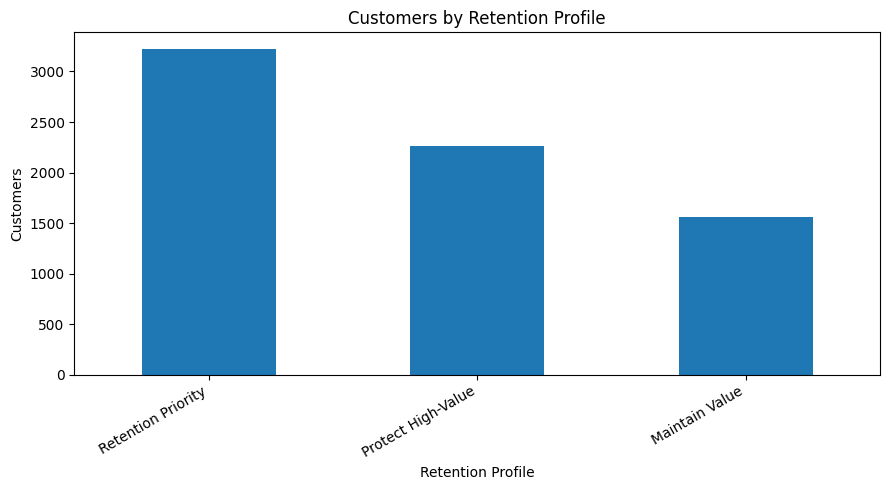

In [7]:
profile_counts = (
    retention_summary
    .groupby("retention_profile")["customers"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
profile_counts.plot(kind="bar", ax=ax)

ax.set_title("Customers by Retention Profile")
ax.set_xlabel("Retention Profile")
ax.set_ylabel("Customers")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 9. Revenue at Risk by Segment

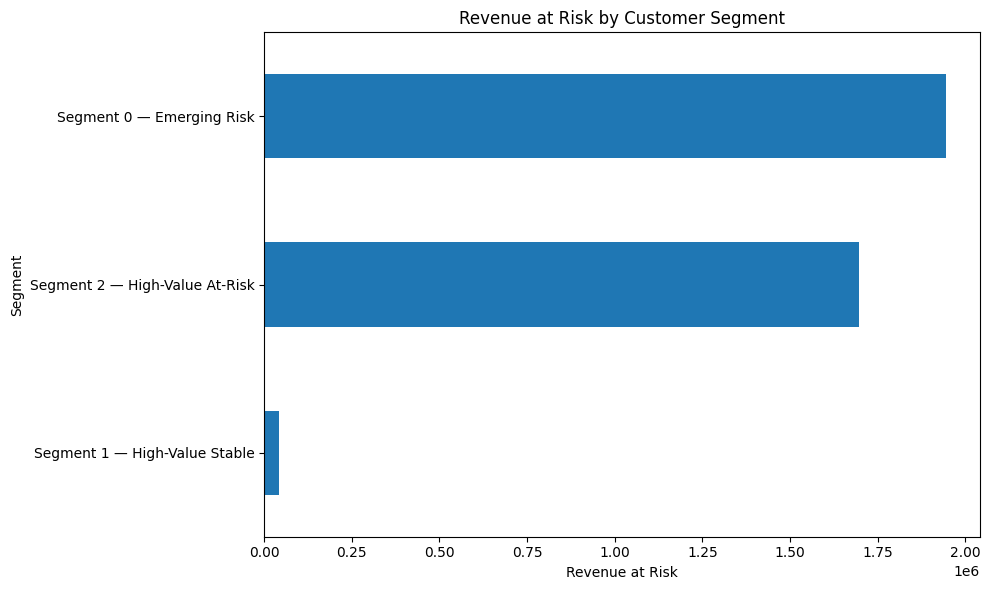

In [8]:
risk_plot = (
    retention_summary
    .set_index("segment_name")["revenue_at_risk"]
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
risk_plot.plot(kind="barh", ax=ax)

ax.set_title("Revenue at Risk by Customer Segment")
ax.set_xlabel("Revenue at Risk")
ax.set_ylabel("Segment")

plt.tight_layout()
plt.show()

## 10. Create MySQL Segmentation Tables

In [9]:
connection = get_connection()
cursor = connection.cursor()

try:
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS customer_segment_assignments (
            customer_id VARCHAR(20) NOT NULL,
            segment_id INT NOT NULL,
            segment_name VARCHAR(120) NOT NULL,
            created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
            PRIMARY KEY (customer_id),
            CONSTRAINT fk_segment_customer
                FOREIGN KEY (customer_id)
                REFERENCES fact_customer_status(customer_id)
        ) ENGINE=InnoDB;
    """)

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS segment_profile_summary (
            segment_id INT NOT NULL,
            segment_name VARCHAR(120) NOT NULL,
            retention_profile VARCHAR(60) NOT NULL,
            customers INT NOT NULL,
            share_pct DECIMAL(8,2) NOT NULL,
            avg_tenure_months DECIMAL(10,2),
            avg_monthly_charge DECIMAL(12,2),
            avg_cltv DECIMAL(14,2),
            avg_satisfaction DECIMAL(8,2),
            churned_customers INT,
            churn_rate_pct DECIMAL(8,2),
            revenue_at_risk DECIMAL(16,2),
            PRIMARY KEY (segment_id)
        ) ENGINE=InnoDB;
    """)

    connection.commit()
    print("MySQL segmentation tables are ready.")

finally:
    cursor.close()
    connection.close()

MySQL segmentation tables are ready.


## 11. Publish Customer Segment Assignments

In [10]:
connection = get_connection()
cursor = connection.cursor()

try:
    cursor.execute("DELETE FROM customer_segment_assignments")

    insert_sql = """
        INSERT INTO customer_segment_assignments (
            customer_id,
            segment_id,
            segment_name
        )
        VALUES (%s, %s, %s)
    """

    rows = [
        (
            str(row.customer_id),
            int(row.segment_id),
            str(row.segment_name)
        )
        for row in assignments.itertuples(index=False)
    ]

    cursor.executemany(insert_sql, rows)
    connection.commit()

    print(
        f"Published {cursor.rowcount:,} customer segment assignments."
    )

finally:
    cursor.close()
    connection.close()

Published 7,043 customer segment assignments.


## 12. Publish Segment Profiles

In [11]:
connection = get_connection()
cursor = connection.cursor()

try:
    cursor.execute("DELETE FROM segment_profile_summary")

    insert_sql = """
        INSERT INTO segment_profile_summary (
            segment_id,
            segment_name,
            retention_profile,
            customers,
            share_pct,
            avg_tenure_months,
            avg_monthly_charge,
            avg_cltv,
            avg_satisfaction,
            churned_customers,
            churn_rate_pct,
            revenue_at_risk
        )
        VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
    """

    rows = [
        (
            int(row.segment_id),
            str(row.segment_name),
            str(row.retention_profile),
            int(row.customers),
            float(row.share_pct),
            float(row.avg_tenure_months),
            float(row.avg_monthly_charge),
            float(row.avg_cltv),
            float(row.avg_satisfaction),
            int(row.churned_customers),
            float(row.churn_rate_pct),
            float(row.revenue_at_risk)
        )
        for row in retention_summary.itertuples(index=False)
    ]

    cursor.executemany(insert_sql, rows)
    connection.commit()

    print(
        f"Published {cursor.rowcount:,} segment profiles."
    )

finally:
    cursor.close()
    connection.close()

Published 3 segment profiles.


## 13. Create MySQL Reporting Views

In [12]:
connection = get_connection()
cursor = connection.cursor()

try:
    cursor.execute("""
        CREATE OR REPLACE VIEW vw_customer_segments AS
        SELECT
            a.customer_id,
            a.segment_id,
            a.segment_name,
            p.retention_profile,
            p.avg_cltv,
            p.churn_rate_pct,
            p.revenue_at_risk,
            a.created_at
        FROM customer_segment_assignments a
        JOIN segment_profile_summary p
            ON a.segment_id = p.segment_id;
    """)

    cursor.execute("""
        CREATE OR REPLACE VIEW vw_segment_retention_summary AS
        SELECT
            segment_id,
            segment_name,
            retention_profile,
            customers,
            share_pct,
            avg_tenure_months,
            avg_monthly_charge,
            avg_cltv,
            avg_satisfaction,
            churned_customers,
            churn_rate_pct,
            revenue_at_risk
        FROM segment_profile_summary;
    """)

    connection.commit()
    print("MySQL reporting views created.")

finally:
    cursor.close()
    connection.close()

MySQL reporting views created.


## 14. Validate the Published Segmentation

In [13]:
connection = get_connection()
cursor = connection.cursor(dictionary=True)

try:
    cursor.execute("""
        SELECT
            (SELECT COUNT(*) FROM fact_customer_status) AS source_customers,
            (SELECT COUNT(*) FROM customer_segment_assignments) AS assigned_customers,
            (SELECT COUNT(*) FROM segment_profile_summary) AS segment_profiles;
    """)

    validation = pd.DataFrame(cursor.fetchall())

finally:
    cursor.close()
    connection.close()

validation

,source_customers,assigned_customers,segment_profiles
0,7043,7043,3


In [14]:
assert int(validation.loc[0, "source_customers"]) == int(
    validation.loc[0, "assigned_customers"]
)

assert int(validation.loc[0, "segment_profiles"]) > 0

print(
    "PASS — every source customer has a segment assignment "
    "and segment profiles are available."
)

PASS — every source customer has a segment assignment and segment profiles are available.


## 15. Export Phase 5 Artifacts

In [15]:
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

assignments.to_csv(
    output_dir / "customer_segment_assignments.csv",
    index=False
)

segment_profile.to_csv(
    output_dir / "segment_profile_summary.csv",
    index=False
)

retention_summary.to_csv(
    output_dir / "segment_retention_profiles.csv",
    index=False
)

print("Phase 5 outputs exported.")

Phase 5 outputs exported.


# Phase 5 Final Conclusion

I created behavior-based customer segments, profiled them using value and retention metrics,
assigned descriptive retention profiles, and published the segmentation layer back into MySQL.

The final segmentation layer provides:

- customer segment assignments
- segment names
- retention profiles
- customer counts and population share
- average CLTV
- tenure
- monthly charge
- satisfaction
- churn rate
- revenue at risk
- MySQL reporting views

**Next:** Phase 6 — Geospatial & Market-Level Retention Analysis.